In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [6]:
listings = pd.read_csv("../Dataset/listings.csv")
reviews = pd.read_csv("../Dataset/reviews.csv")
neighbourhoods = pd.read_csv("../Dataset/neighbourhoods.csv")

print("Listings:", listings.shape)
print("Reviews:", reviews.shape)
print("Neighbourhoods:", neighbourhoods.shape)

Listings: (30555, 19)
Reviews: (990170, 2)
Neighbourhoods: (230, 2)


In [3]:
import os

print(os.getcwd())

/Users/munmunshilaka/Documents/Data-Analytics-Portfolio/08_Projects/Project_02_Airbnb_Business_Intelligence/Notebook


In [4]:
os.listdir()

['Airbnb_Business_Intelligence.ipynb']

In [5]:
os.listdir("../")

['Documentation',
 '.DS_Store',
 'requirements.txt',
 'Images',
 'Dataset',
 'Output',
 'README.md',
 'Notebook',
 'SQL']

In [7]:
listings.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1279666081527148590,"The Broome, Deluxe Queen",NaN,NaN,NaN,Manhattan,SoHo,40.721354,-73.999346,Private room,468.0,1.0,3,2026-02-08,0.57,NaN,338,3,NaN
1,1543683559947083167,"M Social Hotel New York Downtown, Deluxe king ...",NaN,NaN,NaN,Manhattan,Financial District,40.710028,-74.011360,Private room,188.0,1.0,23,2026-05-04,3.37,NaN,265,23,NaN
2,1559522395930572140,"ModernHaus SoHo, SoHo deluxe king",NaN,NaN,NaN,Manhattan,SoHo,40.722680,-74.004830,Private room,431.0,1.0,3,2026-02-22,0.54,NaN,273,3,NaN
3,1665948589959289542,Superior 1-bedroom apartment w/ den & 2 queens,NaN,NaN,NaN,Manhattan,Financial District,40.707529,-74.006188,Private room,257.0,1.0,1,2026-06-10,1.00,NaN,360,1,NaN
4,1394234603510215650,Chic boutique hotel stay | Ameritania Hotel,NaN,NaN,NaN,Manhattan,Midtown,40.764025,-73.982833,Private room,170.0,1.0,168,2026-06-02,12.23,NaN,365,165,NaN


In [8]:
reviews.head()

,listing_id,date
0,2539,2015-12-04
1,2539,2016-08-27
2,2539,2016-10-01
3,2539,2017-02-20
4,2539,2017-03-19


In [9]:
neighbourhoods.head()

,neighbourhood_group,neighbourhood
0,Bronx,Allerton
1,Bronx,Baychester
2,Bronx,Belmont
3,Bronx,Bronxdale
4,Bronx,Castle Hill


In [10]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 30555 entries, 0 to 30554
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              30555 non-null  int64  
 1   name                            30554 non-null  str    
 2   host_id                         30259 non-null  float64
 3   host_profile_id                 29910 non-null  float64
 4   host_name                       29910 non-null  str    
 5   neighbourhood_group             30555 non-null  str    
 6   neighbourhood                   30555 non-null  str    
 7   latitude                        30555 non-null  float64
 8   longitude                       30555 non-null  float64
 9   room_type                       30555 non-null  str    
 10  price                           21797 non-null  float64
 11  minimum_nights                  30553 non-null  float64
 12  number_of_reviews               30555 non-n

In [11]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 990170 entries, 0 to 990169
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   listing_id  990170 non-null  int64
 1   date        990170 non-null  str  
dtypes: int64(1), str(1)
memory usage: 15.1 MB


In [12]:
neighbourhoods.info()

<class 'pandas.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   neighbourhood_group  230 non-null    str  
 1   neighbourhood        230 non-null    str  
dtypes: str(2)
memory usage: 3.7 KB


In [13]:
listings.isnull().sum().sort_values(ascending=False)

license                           25269
price                              8758
last_review                        8616
reviews_per_month                  8616
host_profile_id                     645
host_name                           645
host_id                             296
calculated_host_listings_count      296
minimum_nights                        2
name                                  1
number_of_reviews_ltm                 0
availability_365                      0
id                                    0
number_of_reviews                     0
longitude                             0
latitude                              0
neighbourhood                         0
neighbourhood_group                   0
room_type                             0
dtype: int64

In [14]:
reviews.isnull().sum()

listing_id    0
date          0
dtype: int64

In [15]:
neighbourhoods.isnull().sum()

neighbourhood_group    0
neighbourhood          0
dtype: int64

In [16]:
print("Listings:", listings.duplicated().sum())
print("Reviews:", reviews.duplicated().sum())
print("Neighbourhoods:", neighbourhoods.duplicated().sum())

Listings: 0
Reviews: 32086
Neighbourhoods: 0


In [17]:
listings.describe()

,id,host_id,host_profile_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,3.055500e+04,3.025900e+04,2.991000e+04,30555.000000,30555.000000,21797.000000,30553.000000,30555.000000,21939.000000,30259.000000,30555.000000,30555.000000
mean,6.252408e+17,2.672815e+15,1.469574e+18,40.728740,-73.946784,278.325962,26.642752,32.406153,0.879615,55.887141,186.788283,4.618949
std,6.182099e+17,6.705743e+16,2.417061e+16,0.056260,0.057245,528.538586,27.460851,79.229056,1.984332,174.246090,139.375565,19.188896
min,2.539000e+03,1.678000e+03,1.462506e+18,40.504560,-74.251907,5.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,3.043632e+07,2.069159e+07,1.462882e+18,40.687820,-73.984260,98.000000,30.000000,0.000000,0.090000,1.000000,29.500000,0.000000
50%,6.700833e+17,1.074344e+08,1.465524e+18,40.728731,-73.955796,176.000000,30.000000,4.000000,0.280000,2.000000,209.000000,0.000000
75%,1.164525e+18,3.948700e+08,1.469572e+18,40.761940,-73.927128,304.000000,30.000000,29.000000,1.000000,12.000000,319.000000,2.000000
max,1.707075e+18,1.704453e+18,1.706707e+18,40.912017,-73.711822,30973.000000,1124.000000,4502.000000,115.630000,955.000000,365.000000,1225.000000


In [18]:
listings.describe(include="object")

/var/folders/21/gchfzptn2x3_ys3njlw7gfy00000gn/T/ipykernel_44732/2211706076.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  listings.describe(include="object")


,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review,license
count,30554,29910,30555,30555,30555,21939,5286
unique,29113,7001,5,223,4,3268,2019
top,Water View King Bed Hotel Room,Blueground,Manhattan,Bedford-Stuyvesant,Entire home/apt,2026-05-31,Exempt
freq,30,955,13955,2093,16808,500,2956


In [19]:
listings.columns

Index(['id', 'name', 'host_id', 'host_profile_id', 'host_name',
       'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'last_review', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license'],
      dtype='str')

In [20]:
listings.head(10)

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1279666081527148590,"The Broome, Deluxe Queen",NaN,NaN,NaN,Manhattan,SoHo,40.721354,-73.999346,Private room,468.0,1.0,3,2026-02-08,0.57,NaN,338,3,NaN
1,1543683559947083167,"M Social Hotel New York Downtown, Deluxe king ...",NaN,NaN,NaN,Manhattan,Financial District,40.710028,-74.011360,Private room,188.0,1.0,23,2026-05-04,3.37,NaN,265,23,NaN
2,1559522395930572140,"ModernHaus SoHo, SoHo deluxe king",NaN,NaN,NaN,Manhattan,SoHo,40.722680,-74.004830,Private room,431.0,1.0,3,2026-02-22,0.54,NaN,273,3,NaN
3,1665948589959289542,Superior 1-bedroom apartment w/ den & 2 queens,NaN,NaN,NaN,Manhattan,Financial District,40.707529,-74.006188,Private room,257.0,1.0,1,2026-06-10,1.00,NaN,360,1,NaN
4,1394234603510215650,Chic boutique hotel stay | Ameritania Hotel,NaN,NaN,NaN,Manhattan,Midtown,40.764025,-73.982833,Private room,170.0,1.0,168,2026-06-02,12.23,NaN,365,165,NaN
5,1024580332878266680,"33 Hotel New York City Seaport, Superior court...",NaN,NaN,NaN,Manhattan,Financial District,40.708058,-74.001438,Private room,359.0,1.0,4,2026-01-03,0.31,NaN,352,2,NaN
6,1620340049612392226,"Sixty Les, Queen studio",NaN,NaN,NaN,Manhattan,Lower East Side,40.722190,-73.988640,Private room,246.0,1.0,7,2026-06-06,7.00,NaN,363,7,NaN
7,1643343865444978960,Bunk Pod - Shared Bathroom,NaN,NaN,NaN,Manhattan,Midtown,40.755700,-73.969160,Private room,98.0,1.0,44,2026-05-31,23.16,NaN,315,44,NaN
8,1639160544019164448,"AMTD Idea Tribeca Hotel, 1 King bed",NaN,NaN,NaN,Manhattan,Tribeca,40.720940,-74.005460,Private room,149.0,1.0,11,2026-06-09,8.92,NaN,359,11,NaN
9,1618523976083372756,Hotel Mimosa - Standard queen room,NaN,NaN,NaN,Manhattan,Chinatown,40.714300,-73.993810,Private room,156.0,1.0,3,2026-05-22,1.03,NaN,202,3,NaN


In [21]:
listings.sample(10)

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
22192,51889250,"Cozy room@Queens! Same area W/Target,Costco",200239515.0,1.469045e+18,Shogo,Queens,Rego Park,40.724730,-73.858590,Private room,66.0,30.0,0,NaN,NaN,212.0,31,0,NaN
14837,894060385873877940,Studio with Private Bathroom Midtown Manhattan...,343381111.0,1.469676e+18,Alberto,Manhattan,Midtown,40.745927,-73.987103,Entire home/apt,395.0,1.0,40,2026-04-25,1.08,3.0,272,4,Exempt
17900,45595850,433 West 53-Furnished Studio,51501835.0,1.462720e+18,Jeniffer,Manhattan,Hell's Kitchen,40.767330,-73.987940,Entire home/apt,138.0,30.0,10,2024-12-21,0.17,262.0,172,0,NaN
19834,1340542116785072593,2BR Comfort – Spacious Merged Units w/ Garden ...,472603377.0,1.470131e+18,Emily And Saul,Brooklyn,Fort Hamilton,40.619157,-74.033499,Entire home/apt,279.0,1.0,12,2026-05-31,0.79,63.0,345,7,Exempt
26065,39330170,"Studio in Norwood, \nFordhamUniv/Montefiore",109671307.0,1.462895e+18,Samita,Bronx,Norwood,40.871520,-73.877130,Entire home/apt,102.0,30.0,119,2023-09-05,1.47,3.0,48,0,NaN
5205,46193401,Furnished Junior 1 Bdr Suite in the heart of NYC,120762452.0,1.468228e+18,Stanley,Manhattan,Murray Hill,40.749260,-73.976430,Entire home/apt,155.0,30.0,0,NaN,NaN,83.0,317,0,NaN
25649,4440538,1 private bed room w/ balcony _ Queens NY,23048955.0,1.465268e+18,Mohammed,Queens,Elmhurst,40.736190,-73.873590,Private room,NaN,30.0,17,2021-12-31,0.21,1.0,0,0,NaN
3540,35197500,Spacious & Family-Friendly 2-Bedroom Apartment,121851703.0,1.468237e+18,Mo,Queens,Queens Village,40.720340,-73.734960,Entire home/apt,562.0,30.0,25,2025-08-31,0.29,4.0,348,1,NaN
20480,837909730353865269,LUX in Point,455318910.0,1.470049e+18,Demetra,Queens,College Point,40.787361,-73.845768,Entire home/apt,308.0,30.0,14,2025-08-05,0.36,1.0,333,1,NaN
16632,1163915727550134213,Petite Room Near Bryant Park NYC,446820235.0,1.463723e+18,Luxury Bookings Fze,Manhattan,Murray Hill,40.751211,-73.980299,Entire home/apt,648.0,30.0,0,NaN,NaN,331.0,325,0,NaN


In [22]:
missing = (
    listings.isnull()
            .sum()
            .sort_values(ascending=False)
            .reset_index()
)

missing.columns = ["Column","Missing Values"]

missing

,Column,Missing Values
0,license,25269
1,price,8758
2,last_review,8616
3,reviews_per_month,8616
4,host_profile_id,645
5,host_name,645
6,host_id,296
7,calculated_host_listings_count,296
8,minimum_nights,2
9,name,1


In [23]:
missing["Percentage"] = round(
    missing["Missing Values"] / len(listings) * 100,
    2
)

missing

,Column,Missing Values,Percentage
0,license,25269,82.70
1,price,8758,28.66
2,last_review,8616,28.20
3,reviews_per_month,8616,28.20
4,host_profile_id,645,2.11
5,host_name,645,2.11
6,host_id,296,0.97
7,calculated_host_listings_count,296,0.97
8,minimum_nights,2,0.01
9,name,1,0.00


In [24]:
listings.duplicated().sum()

np.int64(0)

In [25]:
listings["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        13955
Brooklyn         10586
Queens            4703
Bronx              979
Staten Island      332
Name: count, dtype: int64

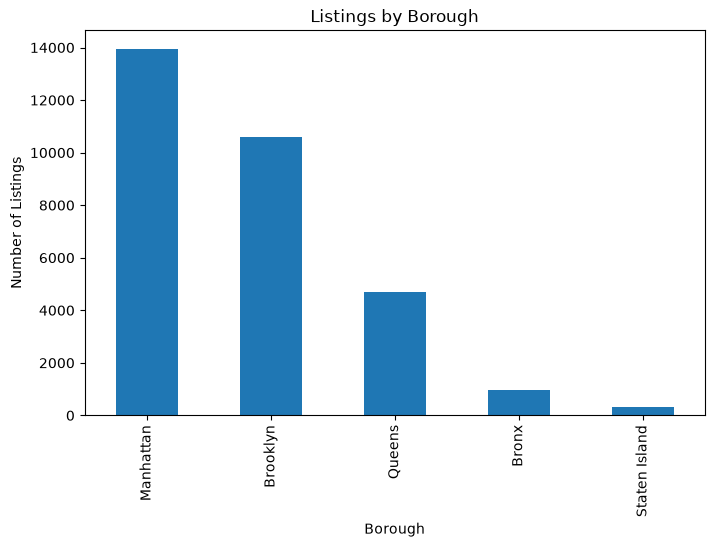

In [26]:
listings["neighbourhood_group"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Listings by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Listings")
plt.show()

In [27]:
listings.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)

neighbourhood_group
Manhattan        379.623887
Brooklyn         213.554179
Queens           175.161078
Bronx            152.850422
Staten Island    143.152027
Name: price, dtype: float64

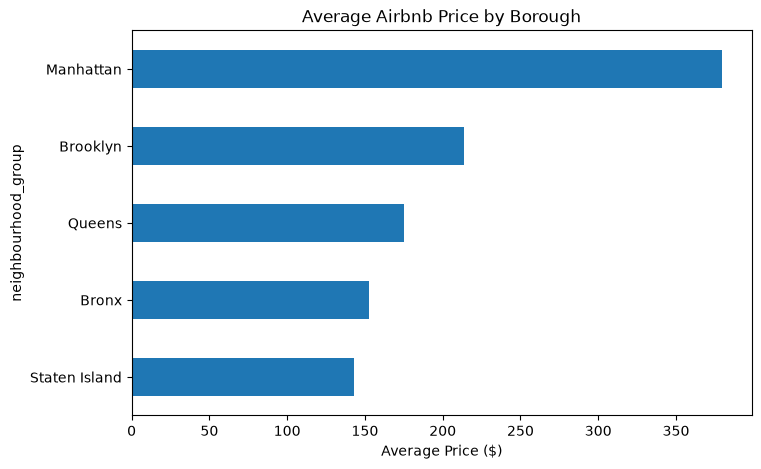

In [28]:
listings.groupby("neighbourhood_group")["price"] \
.mean() \
.sort_values() \
.plot(kind="barh", figsize=(8,5))

plt.title("Average Airbnb Price by Borough")
plt.xlabel("Average Price ($)")
plt.show()

# Data Cleaning & Quality Assessment

In [29]:
listings.dtypes

id                                  int64
name                                  str
host_id                           float64
host_profile_id                   float64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                    float64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                    int64
number_of_reviews_ltm               int64
license                               str
dtype: object

In [30]:
missing = pd.DataFrame({
    "Missing Values": listings.isnull().sum(),
    "Percentage": round(listings.isnull().mean()*100,2)
})

missing = missing[missing["Missing Values"]>0]
missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
license,25269,82.70
price,8758,28.66
last_review,8616,28.20
reviews_per_month,8616,28.20
host_profile_id,645,2.11
host_name,645,2.11
host_id,296,0.97
calculated_host_listings_count,296,0.97
minimum_nights,2,0.01
name,1,0.00


In [31]:
listings.duplicated().sum()

np.int64(0)

In [32]:
listings.nunique().sort_values()

room_type                             4
neighbourhood_group                   5
calculated_host_listings_count       70
minimum_nights                       86
number_of_reviews_ltm               173
neighbourhood                       223
availability_365                    366
number_of_reviews                   531
reviews_per_month                   804
price                              1346
license                            2019
last_review                        3268
host_name                          7001
host_profile_id                   16386
host_id                           16474
longitude                         18720
latitude                          20123
name                              29113
id                                30555
dtype: int64

In [33]:
listings["price"].describe()

count    21797.000000
mean       278.325962
std        528.538586
min          5.000000
25%         98.000000
50%        176.000000
75%        304.000000
max      30973.000000
Name: price, dtype: float64

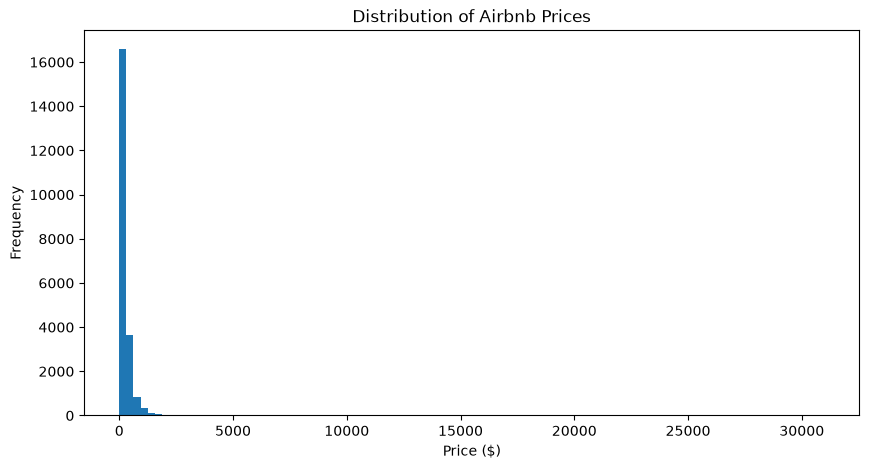

In [34]:
plt.figure(figsize=(10,5))

plt.hist(listings["price"], bins=100)

plt.title("Distribution of Airbnb Prices")

plt.xlabel("Price ($)")

plt.ylabel("Frequency")

plt.show()

In [35]:
listings.sort_values("price", ascending=False).head(20)

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
13652,1685032623471298360,"260 West Broadway, Unit 1/2C",1.685032e+18,1.685033e+18,Wyatt,Manhattan,Tribeca,40.719384,-74.004995,Entire home/apt,30973.0,30.0,0,NaN,NaN,1.0,365,0,NaN
21515,1111666023012679487,Opulent Midtown Retreat with White-Gloved Service,5.019993e+08,1.468058e+18,RoomPicks,Manhattan,Upper East Side,40.765030,-73.971670,Hotel room,14864.0,1.0,0,NaN,NaN,152.0,344,0,Exempt
22690,1111666150326773564,"Presidential Suite Park View King Bed, The Pierre",5.019993e+08,1.468058e+18,RoomPicks,Manhattan,Upper East Side,40.765030,-73.971670,Hotel room,14864.0,1.0,0,NaN,NaN,152.0,345,0,Exempt
7587,990529,Sunny Luxury Bedroom Guest Bathroom,5.440087e+06,1.462681e+18,Dn,Manhattan,Murray Hill,40.749360,-73.971960,Private room,12279.0,30.0,3,2014-09-24,0.02,2.0,83,0,NaN
7390,1623431,Enormous Chrysler-View Bedroom/Bath,5.440087e+06,1.462681e+18,Dn,Manhattan,Midtown,40.749670,-73.970090,Private room,12078.0,30.0,1,2015-09-30,0.01,2.0,83,0,NaN
8298,830682282357157632,North Gallery Café,7.616643e+07,1.462817e+18,Joel,Manhattan,Midtown,40.765540,-73.982930,Entire home/apt,11062.0,30.0,0,NaN,NaN,3.0,365,0,NaN
3423,830656153550799267,"Eighth House, State of the Art NYC Venue",7.616643e+07,1.462817e+18,Joel,Manhattan,Midtown,40.764694,-73.982688,Entire home/apt,11062.0,30.0,0,NaN,NaN,3.0,365,0,NaN
12457,1614018340350324380,Empire State Views | Bar. Live Jazz + City Views,5.667787e+08,1.470523e+18,NH Collection New York Madison Avenue,Manhattan,Midtown,40.751006,-73.981346,Private room,10986.0,1.0,0,NaN,NaN,4.0,293,0,Exempt
29942,1614020137045877415,Walk to Empire State | Gym. Live Jazz. Bar On-...,5.667787e+08,1.470523e+18,NH Collection New York Madison Avenue,Manhattan,Murray Hill,40.748877,-73.979718,Private room,10986.0,1.0,0,NaN,NaN,4.0,278,0,Exempt
30000,1614018927799603136,Near Fifth Ave | Bar. Pet-Friendly + Fine Dining,5.667787e+08,1.470523e+18,NH Collection New York Madison Avenue,Manhattan,Midtown,40.750250,-73.981770,Private room,10986.0,1.0,0,NaN,NaN,4.0,276,0,Exempt


In [36]:
listings.sort_values("price").head(20)

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
17226,718389176579416848,Very good atmosphere,479928815.0,1.470162e+18,Natanael,Manhattan,Harlem,40.830520,-73.946262,Private room,5.0,365.0,0,NaN,NaN,1.0,365,0,NaN
25519,3891031,LAST DAY TO BOOK Bedroom on Wall St,20133610.0,1.463100e+18,Shi Qing,Manhattan,Financial District,40.707780,-74.004800,Private room,7.0,365.0,11,2014-12-27,0.08,1.0,365,0,NaN
28864,860932964024906492,Small Sunny Room in Park Slope,171051361.0,1.468662e+18,Elizabeth,Brooklyn,Sunset Park,40.660360,-73.993490,Private room,7.0,180.0,4,2025-02-02,0.13,2.0,234,0,NaN
29709,586798321587331719,Be my roommate!,131115416.0,1.468313e+18,Kat,Staten Island,Emerson Hill,40.606429,-74.119116,Private room,10.0,130.0,0,NaN,NaN,2.0,269,0,NaN
30285,1214636499668232791,Unfurnished 2BR UES 12 month MIN,23772724.0,1.462627e+18,The Local Stay,Manhattan,Upper East Side,40.783160,-73.947320,Entire home/apt,10.0,364.0,0,NaN,NaN,76.0,365,0,NaN
1669,691569646575996680,Semi-Private Basic - Midtown Manhattan,406915877.0,1.469860e+18,Harrington,Manhattan,Midtown,40.759680,-73.979050,Private room,11.0,180.0,0,NaN,NaN,4.0,364,0,NaN
24441,547058790481548248,"Great Location, Clean Room w Private Bathroom",309662254.0,1.469577e+18,Beyza,Manhattan,Chelsea,40.746120,-73.995210,Private room,11.0,360.0,0,NaN,NaN,1.0,364,0,NaN
24501,19413467,Nice Room (2 people) with private Bathroom in NYC,136101875.0,1.468356e+18,Sizhe,Manhattan,Upper West Side,40.773690,-73.992370,Private room,11.0,360.0,7,2018-05-25,0.07,1.0,365,0,NaN
29883,1174252633024473480,Charming Oasis by the Park,82502574.0,1.467001e+18,John,Manhattan,Washington Heights,40.857512,-73.935890,Entire home/apt,11.0,365.0,0,NaN,NaN,1.0,365,0,NaN
464,871990853610302281,Detached Cozy Private Studio,484563208.0,1.470182e+18,Tricia,Queens,Howard Beach,40.663586,-73.834532,Entire home/apt,11.0,365.0,0,NaN,NaN,2.0,365,0,NaN


# Business Questions

This analysis aims to answer the following business questions:

1. Which borough generates the highest Airbnb revenue potential?
2. Which neighborhoods have the highest average listing price?
3. Which room type is most popular?
4. Which room type generates the highest revenue?
5. Which hosts own the largest number of listings?
6. Does price affect customer reviews?
7. Which areas have the highest customer satisfaction?
8. Are expensive listings receiving more reviews?
9. What pricing strategy should Airbnb recommend?
10. What business opportunities exist for hosts?

In [37]:
borough_counts = listings["neighbourhood_group"].value_counts()

borough_counts

neighbourhood_group
Manhattan        13955
Brooklyn         10586
Queens            4703
Bronx              979
Staten Island      332
Name: count, dtype: int64

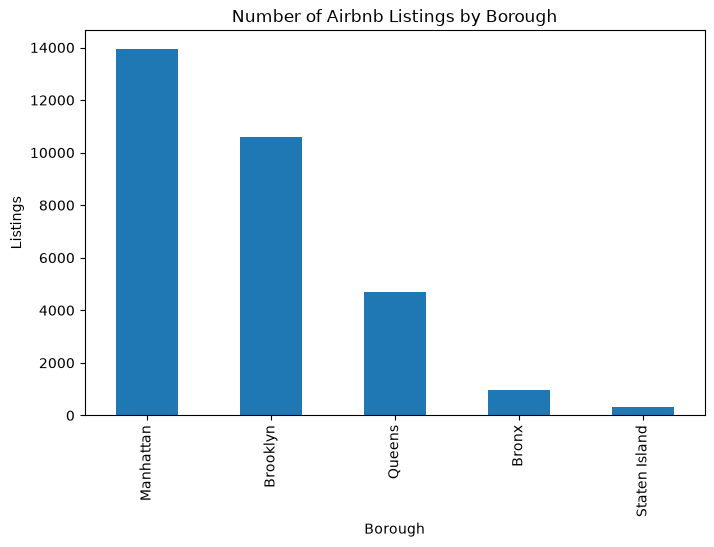

In [38]:
borough_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Number of Airbnb Listings by Borough")
plt.xlabel("Borough")
plt.ylabel("Listings")

plt.show()

### Insight

Manhattan has the largest number of Airbnb listings, followed by Brooklyn.

This indicates that Airbnb supply is concentrated in these two boroughs, making them the company's most competitive markets.

In [39]:
avg_price = listings.groupby(
    "neighbourhood_group"
)["price"].mean().sort_values(ascending=False)

avg_price

neighbourhood_group
Manhattan        379.623887
Brooklyn         213.554179
Queens           175.161078
Bronx            152.850422
Staten Island    143.152027
Name: price, dtype: float64

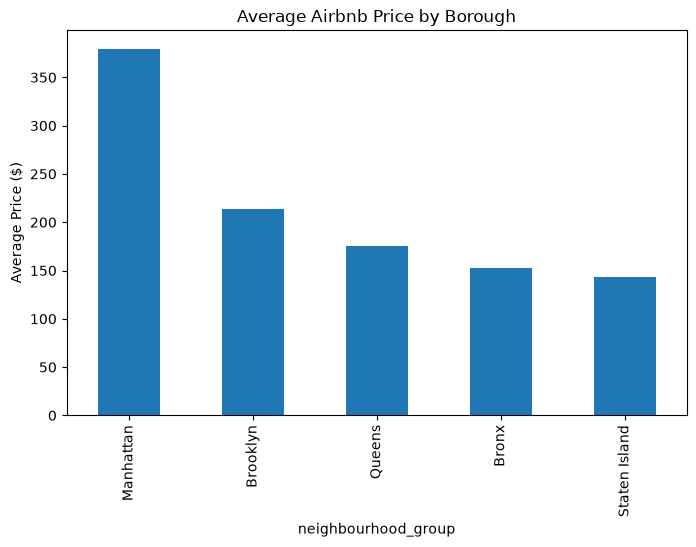

In [40]:
avg_price.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Airbnb Price by Borough")
plt.ylabel("Average Price ($)")

plt.show()

### Insight

Manhattan has the highest average Airbnb price.

This suggests guests are willing to pay a premium for central locations.

Queens and Bronx remain relatively affordable markets.

In [41]:
room_type = listings["room_type"].value_counts()

room_type

room_type
Entire home/apt    16808
Private room       13009
Hotel room           520
Shared room          218
Name: count, dtype: int64

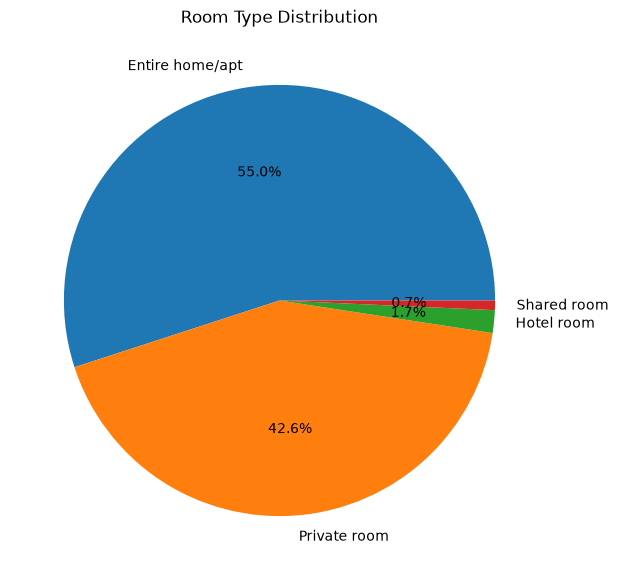

In [42]:
room_type.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.ylabel("")

plt.title("Room Type Distribution")

plt.show()

In [43]:
listings.groupby("room_type")["price"].mean().sort_values()

room_type
Shared room        164.390625
Private room       194.522632
Entire home/apt    331.426454
Hotel room         721.579167
Name: price, dtype: float64

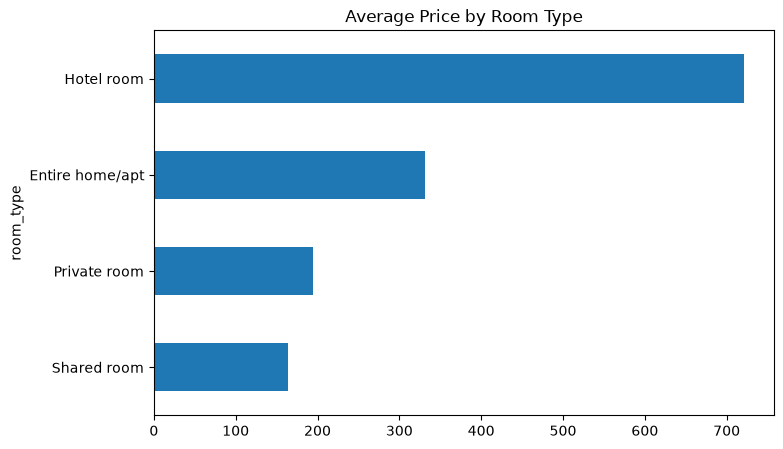

In [44]:
listings.groupby("room_type")["price"].mean().sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Average Price by Room Type")

plt.show()

# Host Performance Analysis

In [45]:
top_hosts = (
    listings.groupby("host_name")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_hosts

host_name
Blueground             955
Kristina               521
Luxury Bookings Fze    331
Michael                319
Jeniffer               310
Urban Furnished        255
Hiroki                 239
LEAP NY Apartments     217
RoomPicks              216
Shogo                  212
dtype: int64

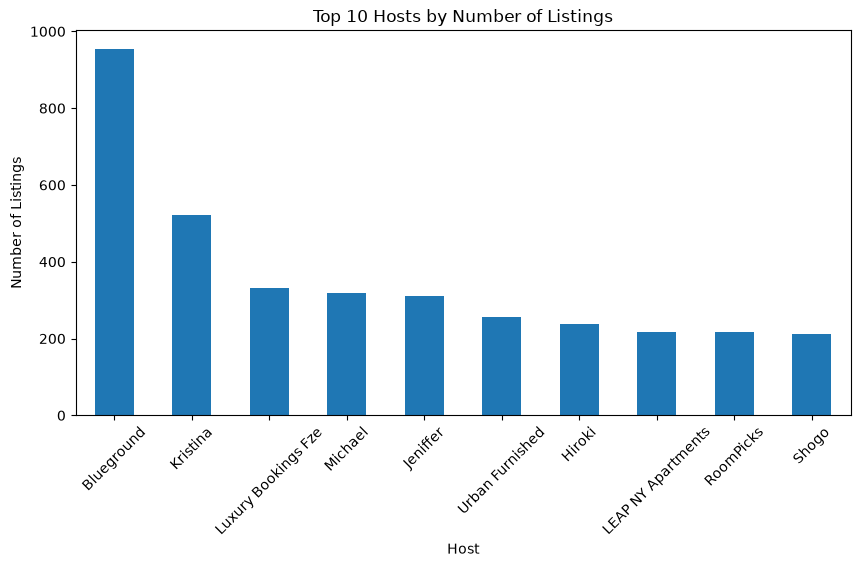

In [46]:
top_hosts.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Hosts by Number of Listings")
plt.xlabel("Host")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)

plt.show()

### Insight

A small number of hosts manage a disproportionately large number of listings.

This indicates the presence of professional property managers alongside individual hosts.

In [47]:
top_neighbourhoods = (
    listings.groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

top_neighbourhoods

neighbourhood
Country Club          1384.333333
Tribeca               1178.435897
Fort Wadsworth        1010.000000
Civic Center           978.750000
Riverdale              735.000000
Navy Yard              668.000000
Brooklyn Heights       605.571429
Financial District     565.023669
West Village           549.527174
Flatiron District      544.811321
Midtown                531.755356
SoHo                   525.765823
NoHo                   503.750000
Greenwich Village      496.807692
Murray Hill            488.002747
Name: price, dtype: float64

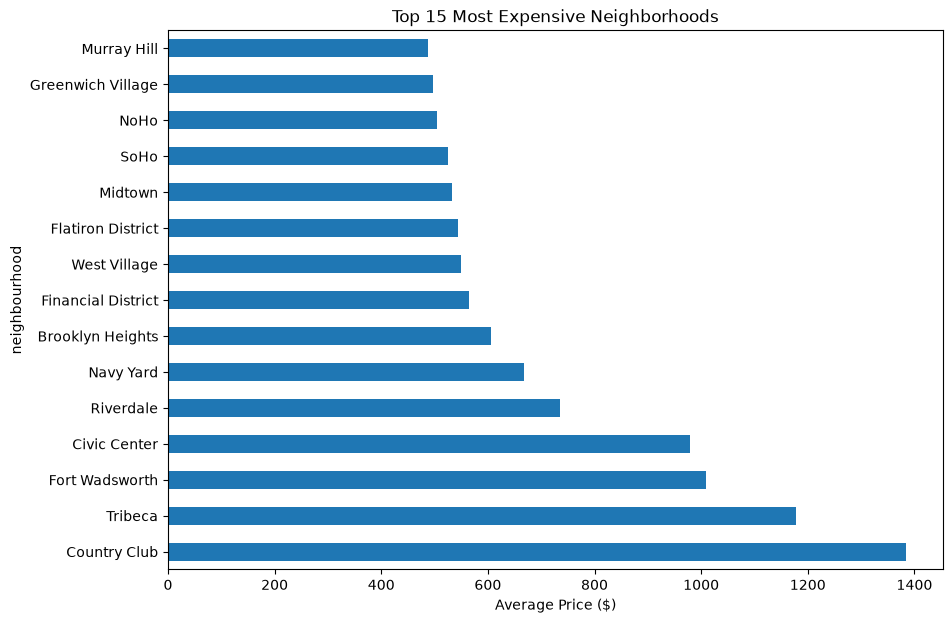

In [48]:
top_neighbourhoods.plot(
    kind="barh",
    figsize=(10,7)
)

plt.title("Top 15 Most Expensive Neighborhoods")
plt.xlabel("Average Price ($)")

plt.show()

In [49]:
cheap_neighbourhoods = (
    listings.groupby("neighbourhood")["price"]
    .mean()
    .sort_values()
    .head(15)
)

cheap_neighbourhoods

neighbourhood
Woodrow                   63.000000
Co-op City                67.400000
Hunts Point               70.500000
Chelsea, Staten Island    73.000000
Highbridge                73.250000
Bronxdale                 74.000000
Olinville                 84.800000
South Beach               85.428571
Mount Eden                86.000000
Fordham                   88.914286
Elmhurst                  89.106918
Edenwald                  90.000000
Graniteville              91.333333
Mount Hope                91.727273
Little Neck               94.250000
Name: price, dtype: float64

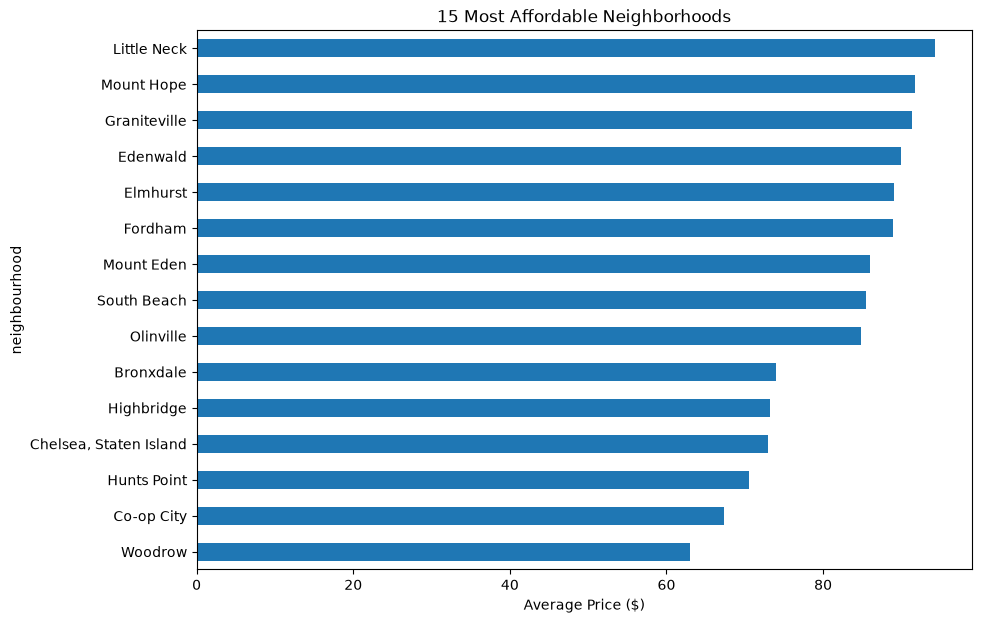

In [50]:
cheap_neighbourhoods.plot(
    kind="barh",
    figsize=(10,7)
)

plt.title("15 Most Affordable Neighborhoods")
plt.xlabel("Average Price ($)")

plt.show()

# Customer Review Analysis

In [51]:
top_reviewed = (
    listings[
        ["name", "host_name", "number_of_reviews", "price"]
    ]
    .sort_values("number_of_reviews", ascending=False)
    .head(15)
)

top_reviewed

,name,host_name,number_of_reviews,price
12254,"Safe and Cozy Hostel Room, 1 person, Manhattan",Alfred,4502,90.0
8775,Soho Sanctuary - Hotel Room,SOBECA At SoHo Garden Hotel,2349,138.0
8746,Untitled at 3 Freeman - Studio Queen,Untitled,2336,237.0
9002,Amazing Micro Unit W/ communal rooftop and kit...,The Ridge,2006,165.0
12279,Steps to Times Square | Full Kitchen. Pet-Frie...,Candlewood Suites Times Square,1669,157.0
8708,Serene Soho - Tribeca Stay Hotel Comfort,SOBECA At SoHo Garden Hotel,1409,138.0
28653,Steps to Times Square | Free Breakfast & Fitness,Times Square South New York City,1376,345.0
12227,Individual Cubicle Room in NYC / Mixed Floor,Alex & Zinaida,1327,110.0
8702,Untitled at 3 Freeman - Studio Mini,Untitled,1262,221.0
9023,Beautiful Standard Full Room at The Ridge,The Ridge,1235,210.0


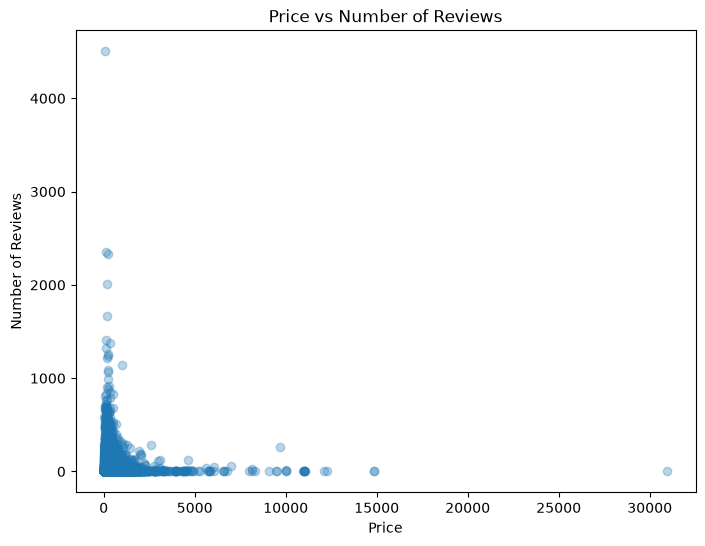

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(
    listings["price"],
    listings["number_of_reviews"],
    alpha=0.3
)

plt.xlabel("Price")
plt.ylabel("Number of Reviews")
plt.title("Price vs Number of Reviews")

plt.show()

### Insight

Most highly reviewed listings fall within the lower to mid-price range.

Luxury listings generally receive fewer reviews, suggesting demand is concentrated in affordable accommodations.

In [53]:
listings["estimated_revenue"] = (
    listings["price"] *
    listings["number_of_reviews"]
)

In [54]:
borough_revenue = (
    listings.groupby("neighbourhood_group")
    ["estimated_revenue"]
    .sum()
    .sort_values(ascending=False)
)

borough_revenue

neighbourhood_group
Manhattan        98620849.0
Brooklyn         79150552.0
Queens           27350378.0
Bronx             3711676.0
Staten Island     1820509.0
Name: estimated_revenue, dtype: float64

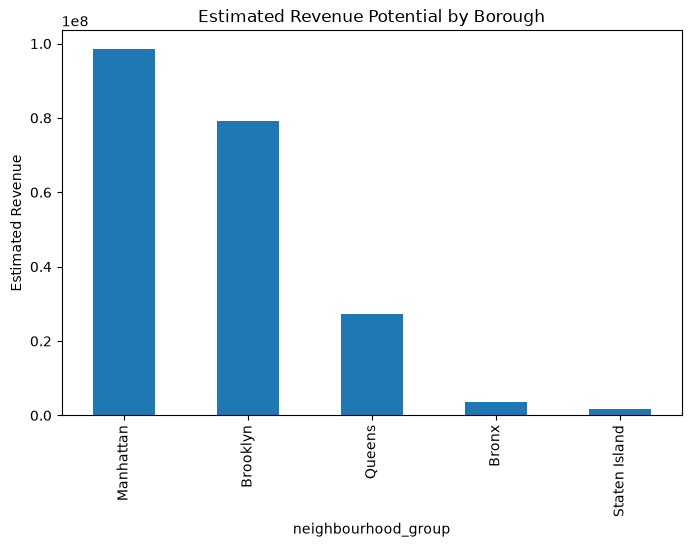

In [55]:
borough_revenue.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Estimated Revenue Potential by Borough")

plt.ylabel("Estimated Revenue")

plt.show()

In [56]:
borough_avg = (
    listings.groupby("neighbourhood_group")
    ["price"]
    .transform("mean")
)

listings["price_difference"] = (
    listings["price"] - borough_avg
)

In [57]:
listings.sort_values(
    "price_difference",
    ascending=False
)[
    [
        "name",
        "neighbourhood_group",
        "price",
        "price_difference"
    ]
].head(20)

,name,neighbourhood_group,price,price_difference
13652,"260 West Broadway, Unit 1/2C",Manhattan,30973.0,30593.376113
22690,"Presidential Suite Park View King Bed, The Pierre",Manhattan,14864.0,14484.376113
21515,Opulent Midtown Retreat with White-Gloved Service,Manhattan,14864.0,14484.376113
7587,Sunny Luxury Bedroom Guest Bathroom,Manhattan,12279.0,11899.376113
7390,Enormous Chrysler-View Bedroom/Bath,Manhattan,12078.0,11698.376113
20594,WELCOME HOME 15 MINUTES TO MANHATTAN BOOK TODAY,Bronx,10945.0,10792.149578
3423,"Eighth House, State of the Art NYC Venue",Manhattan,11062.0,10682.376113
8298,North Gallery Café,Manhattan,11062.0,10682.376113
29942,Walk to Empire State | Gym. Live Jazz. Bar On-...,Manhattan,10986.0,10606.376113
12457,Empire State Views | Bar. Live Jazz + City Views,Manhattan,10986.0,10606.376113


In [58]:
listings.sort_values(
    "price_difference"
)[
    [
        "name",
        "neighbourhood_group",
        "price",
        "price_difference"
    ]
].head(20)

,name,neighbourhood_group,price,price_difference
17226,Very good atmosphere,Manhattan,5.0,-374.623887
25519,LAST DAY TO BOOK Bedroom on Wall St,Manhattan,7.0,-372.623887
30285,Unfurnished 2BR UES 12 month MIN,Manhattan,10.0,-369.623887
1669,Semi-Private Basic - Midtown Manhattan,Manhattan,11.0,-368.623887
24501,Nice Room (2 people) with private Bathroom in NYC,Manhattan,11.0,-368.623887
29883,Charming Oasis by the Park,Manhattan,11.0,-368.623887
24441,"Great Location, Clean Room w Private Bathroom",Manhattan,11.0,-368.623887
18581,Deluxe Room - Midtown East,Manhattan,12.0,-367.623887
17397,Middle Room In Warm & Friendly Apartment,Manhattan,12.0,-367.623887
19344,"Times Square, Huge 1 bedroom Loft Apartment",Manhattan,13.0,-366.623887


In [59]:
listings["premium_index"] = (
    listings["price"] /
    borough_avg
)

In [60]:
listings.sort_values(
    "premium_index",
    ascending=False
)[
    [
        "name",
        "neighbourhood_group",
        "price",
        "premium_index"
    ]
].head(20)

,name,neighbourhood_group,price,premium_index
13652,"260 West Broadway, Unit 1/2C",Manhattan,30973.0,81.588649
20594,WELCOME HOME 15 MINUTES TO MANHATTAN BOOK TODAY,Bronx,10945.0,71.605952
19187,"Paper Factory, Deluxe King",Queens,10000.0,57.090309
19186,"Paper Factory, Executive King",Queens,10000.0,57.090309
16138,"Paper Factory, Superior Room w/ Double Beds",Queens,10000.0,57.090309
3501,House located in the heart of Brooklyn Heights,Brooklyn,9108.0,42.649599
22690,"Presidential Suite Park View King Bed, The Pierre",Manhattan,14864.0,39.154544
21515,Opulent Midtown Retreat with White-Gloved Service,Manhattan,14864.0,39.154544
11905,NYC Firehouse-Greenpoint BRKLYN,Brooklyn,8171.0,38.261953
5362,Cozy Brooklyn Brownstone,Brooklyn,8143.0,38.130839


In [61]:
value = (
    listings.groupby("neighbourhood_group")
    .agg({
        "price":"mean",
        "number_of_reviews":"mean"
    })
)

value["value_score"] = (
    value["number_of_reviews"] /
    value["price"]
)

value.sort_values(
    "value_score",
    ascending=False
)

,price,number_of_reviews,value_score
neighbourhood_group,,,
Staten Island,143.152027,40.662651,0.284052
Bronx,152.850422,31.391216,0.205372
Queens,175.161078,35.882203,0.204853
Brooklyn,213.554179,38.703287,0.181234
Manhattan,379.623887,26.332569,0.069365


# Business Case Study 1

## Problem

Airbnb wants to expand marketing investment.

Which borough offers the best opportunity?

We will compare:

- Listings
- Average Price
- Average Reviews
- Estimated Revenue

In [62]:
borough_summary = (
    listings.groupby("neighbourhood_group")
    .agg(
        Total_Listings=("id","count"),
        Average_Price=("price","mean"),
        Average_Reviews=("number_of_reviews","mean"),
        Estimated_Revenue=("estimated_revenue","sum")
    )
)

borough_summary.round(2)

,Total_Listings,Average_Price,Average_Reviews,Estimated_Revenue
neighbourhood_group,,,,
Bronx,979,152.85,31.39,3711676.0
Brooklyn,10586,213.55,38.70,79150552.0
Manhattan,13955,379.62,26.33,98620849.0
Queens,4703,175.16,35.88,27350378.0
Staten Island,332,143.15,40.66,1820509.0


In [63]:
room_summary = (
    listings.groupby("room_type")
    .agg(
        Listings=("id","count"),
        Average_Price=("price","mean"),
        Average_Reviews=("number_of_reviews","mean"),
        Estimated_Revenue=("estimated_revenue","sum")
    )
)

room_summary.round(2)

,Listings,Average_Price,Average_Reviews,Estimated_Revenue
room_type,,,,
Entire home/apt,16808,331.43,27.05,114016709.0
Hotel room,520,721.58,10.15,1604028.0
Private room,13009,194.52,40.22,93009192.0
Shared room,218,164.39,32.58,2024035.0


In [64]:
premium = (
    listings.groupby("neighbourhood")
    .agg(
        Listings=("id","count"),
        Avg_Price=("price","mean"),
        Avg_Reviews=("number_of_reviews","mean")
    )
)

premium.sort_values(
    "Avg_Price",
    ascending=False
).head(20)

,Listings,Avg_Price,Avg_Reviews
neighbourhood,,,
Country Club,4,1384.333333,6.500000
Tribeca,141,1178.435897,20.092199
Fort Wadsworth,1,1010.000000,0.000000
Civic Center,15,978.750000,23.666667
Riverdale,4,735.000000,67.000000
Navy Yard,5,668.000000,3.000000
Brooklyn Heights,56,605.571429,27.678571
Financial District,619,565.023669,27.967690
West Village,382,549.527174,19.984293


In [65]:
overpriced = listings[
    listings["price"] >
    listings["price"].quantile(.95)
]

overpriced[
    [
        "name",
        "neighbourhood_group",
        "price",
        "number_of_reviews"
    ]
].head(20)

,name,neighbourhood_group,price,number_of_reviews
60,Penthouse Oasis in Brooklyn Clouds,Brooklyn,1082.0,0
70,Luxurious 2 bd 2 bath Manhattan,Manhattan,1002.0,0
80,Custom-Designed Conference Loft Brooklyn,Brooklyn,3982.0,0
85,Loft best block in East Village,Manhattan,2159.0,1
97,RoveTravel | Elk Terrace | Home w/Private Terrace,Manhattan,1938.0,0
141,Contemporary 3BR Stay in Midtown Manhattan,Manhattan,2854.0,0
150,Newly renovated loft in Brooklyn!,Brooklyn,1817.0,0
263,Park Row Pad,Manhattan,1012.0,0
272,Cozy Luxury Retro Aesthetic Bedroom,Manhattan,1164.0,0
383,Studio King Room | 5th Ave | Full Sofabed,Manhattan,969.0,1


In [66]:
host_business = (
    listings.groupby("host_name")
    .size()
    .sort_values(ascending=False)
)

host_business.head(20)

host_name
Blueground             955
Kristina               521
Luxury Bookings Fze    331
Michael                319
Jeniffer               310
Urban Furnished        255
Hiroki                 239
LEAP NY Apartments     217
RoomPicks              216
Shogo                  212
Momoyo                 205
David                  172
Kaz                    157
Rove Travel            156
Furnished Quarters     151
⁨StayWithVibe.⁩        148
Alex                   145
Daniel                 135
Justin                 132
John                   123
dtype: int64

# Airbnb New York City Business Intelligence & Market Strategy Report

1. Executive Summary

2. Business Problem

3. Business Objectives

4. Dataset Overview

5. Data Cleaning & Quality Assessment

6. Exploratory Data Analysis

7. Business Case Studies

8. Business Recommendations

9. Conclusion

10. Future Improvements

# Dataset Overview

Source:
Inside Airbnb (New York City)

Data Files:
- listings.csv
- reviews.csv
- neighbourhoods.csv

Analysis Period:
Latest Available Dataset (2025–2026)

Total Listings:
30,555

Total Reviews:
990,170

Total Neighbourhoods:
223

Total Boroughs:
5

In [67]:
total_listings = listings.shape[0]

total_hosts = listings["host_id"].nunique()

total_neighbourhoods = listings["neighbourhood"].nunique()

total_reviews = listings["number_of_reviews"].sum()

average_price = listings["price"].mean()

average_minimum_nights = listings["minimum_nights"].mean()

print("Total Listings:", total_listings)
print("Total Hosts:", total_hosts)
print("Total Neighbourhoods:", total_neighbourhoods)
print("Total Reviews:", total_reviews)
print("Average Price:", round(average_price,2))
print("Average Minimum Nights:", round(average_minimum_nights,2))

Total Listings: 30555
Total Hosts: 16474
Total Neighbourhoods: 223
Total Reviews: 990170
Average Price: 278.33
Average Minimum Nights: 26.64


In [68]:
borough_dashboard = (
    listings.groupby("neighbourhood_group")
    .agg(
        Listings=("id","count"),
        Hosts=("host_id","nunique"),
        Average_Price=("price","mean"),
        Average_Reviews=("number_of_reviews","mean"),
        Estimated_Revenue=("estimated_revenue","sum")
    )
    .round(2)
)

borough_dashboard

,Listings,Hosts,Average_Price,Average_Reviews,Estimated_Revenue
neighbourhood_group,,,,,
Bronx,979,665,152.85,31.39,3711676.0
Brooklyn,10586,7361,213.55,38.70,79150552.0
Manhattan,13955,5762,379.62,26.33,98620849.0
Queens,4703,2691,175.16,35.88,27350378.0
Staten Island,332,228,143.15,40.66,1820509.0


# Feature Engineering

In [70]:
listings["price_category"] = pd.cut(
    listings["price"],
    bins=[0,50,100,200,500,100000],
    labels=[
        "Budget",
        "Economy",
        "Standard",
        "Premium",
        "Luxury"
    ]
)

listings["price_category"].value_counts()

price_category
Premium     7099
Standard    6661
Economy     4750
Luxury      2396
Budget       891
Name: count, dtype: int64

In [71]:
listings["review_category"] = pd.cut(
    listings["number_of_reviews"],
    bins=[-1,10,50,100,500,100000],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

listings["review_category"].value_counts()

review_category
Very Low     18781
Low           6291
High          2847
Medium        2546
Very High       90
Name: count, dtype: int64

In [72]:
host_counts = listings.groupby("host_id")["id"].transform("count")

listings["host_portfolio"] = pd.cut(
    host_counts,
    bins=[0,1,5,20,1000],
    labels=[
        "Single Listing",
        "Small Portfolio",
        "Professional Host",
        "Property Company"
    ]
)

listings["host_portfolio"].value_counts()

host_portfolio
Single Listing       13274
Small Portfolio       6904
Property Company      6342
Professional Host     3739
Name: count, dtype: int64

In [73]:
listings["revenue_category"] = pd.cut(
    listings["estimated_revenue"],
    bins=[-1,5000,20000,100000,1000000],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

listings["revenue_category"].value_counts()

revenue_category
Low          15486
Medium        3418
High          2591
Very High      300
Name: count, dtype: int64